In [ ]:
import sys
import os


import jax
from jax import random
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from modules.kgd_functions import F_P, GradientKernel,KernelGradientDiscrepancy, k_imq, imq_scale_mixtures, MMD, recommended_kernel
from modules.mfld import MeanFieldLangevinDynamics

import import_ipynb
from lotka_volterra import gradL_ms,true_params

In [14]:
kernel_name = "recommended_kernel"

In the miss-specified case.

In [3]:
def grad_log_q0(X):
    return -X

# no need of the function L because gradL is provided
def L(X):
    return 0 

gamma = 10.0
gradL = lambda X: gradL_ms(X,gamma)

MFLD = MeanFieldLangevinDynamics(grad_log_q0,L,gradL = gradL)  

In [4]:
n = 25
step_size = 1e-5
T = 5000

key = random.PRNGKey(2024)
n_particles = 25
params_init = jnp.stack([true_params] * n_particles, 0)
key, subkey = random.split(key)
X0 = params_init + 1e-5 * random.normal(subkey, params_init.shape)

all_particles = MFLD.run_particles(step_size,T,X0,key)
X_fin = all_particles[-1]

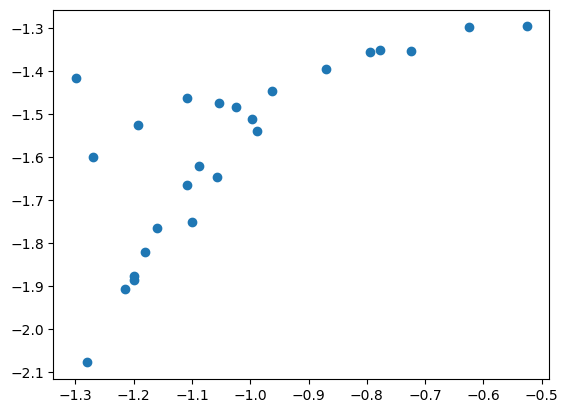

In [39]:
# Final particles position
plt.scatter(X_fin[:,0],X_fin[:,1],label='Final particles')
plt.show()

In [ ]:
import jax.numpy as jnp
import pickle

expe3_filename_evol_particles = f"saved_data/expe3_evol_particles_{gamma}_{kernel_name}.pkl"
#load
with open(expe3_filename_evol_particles, "rb") as g:
    expe3_evol_particles = pickle.load(g)

In [31]:
iterations_gradL = jnp.array([1,10**3,10**4,10**5])
particles_position = all_particles[iterations_gradL//n,:,:]
expe3_evol_particles["MFLD"]["iterations_gradL"] = iterations_gradL
expe3_evol_particles["MFLD"]["particles_position"] = particles_position

In [32]:
import pickle

# Save
with open(expe3_filename_evol_particles, "wb") as gg:
    pickle.dump(expe3_evol_particles, gg)

# Trajectory

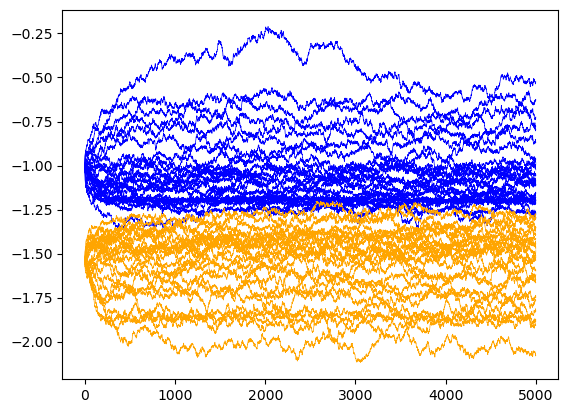

In [ ]:
plt.plot(all_particles[:,:,0],color = "blue",label = "dim 1",linewidth = 0.5)
plt.plot(all_particles[:,:,1],color = "orange",label = "dim 2",linewidth = 0.5)
plt.show()

Try different lengthscales for KGD IMQ kernel.

In [27]:
filename = f"saved_data/expe3_results_gamma_{gamma}_{kernel_name}.pkl"
import jax.numpy as jnp
import pickle

# Chargement depuis le fichier
with open(filename, "rb") as g:
    expe3_results = pickle.load(g)

In [ ]:
evaluations_grad_L = jnp.arange(0,T) * n
scales = [1e3,1e2,1e1,1,1e-1,1e-2,1e-3,1e-4]

KGD_scales = []
MMD_scales = []
for scale in scales:
    k = lambda x,y : k_imq(x,y,1.,0.5,scale)
    k_pq = GradientKernel(MFLD.S_PQ,k)
    KGD = KernelGradientDiscrepancy(k_pq)
    k_mmd = lambda x,y : k_imq(x,y,1,0.5,scale)
    KGD_values_l = []
    MMD_values_l = []
    for it in range(T):
        KGD_values_l.append(KGD.evaluate(all_particles[it]))
        MMD_values_l.append(MMD(all_particles[it],expe3_results["MFLD contour"]["X_fin"],k_mmd))
    plt.plot(evaluations_grad_L,KGD_values_l,label='scale = '+str(scale),alpha = 0.5)
    KGD_scales.append(jnp.array(KGD_values_l))
    MMD_scales.append(jnp.array(MMD_values_l))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of evaluations of grad L')
plt.ylabel('KSD')
plt.legend()
plt.show()

In [ ]:
filename_lengthscales = f"saved_data/kgd_lengthscales_gamma_{gamma}.pkl"

In [ ]:
import jax.numpy as jnp
import pickle

# load
with open(filename_lengthscales, "rb") as g:
    kgd_lengthscales = pickle.load(g)

In [ ]:
kgd_lengthscales["MFLD"]["Scales"] = scales
kgd_lengthscales["MFLD"]["KGD_scales"] = KGD_scales
kgd_lengthscales["MFLD"]["MMD_scales"] = MMD_scales

In [ ]:
import pickle

# save
with open(filename_lengthscales, "wb") as gg:
    pickle.dump(kgd_lengthscales, gg)

KGD for curve for figure 3

In [33]:
if kernel_name == "imq":
    scale = 0.1
    k = jit(lambda x, y: k_imq(x, y, 1, 0.5, scale))
elif kernel_name == "recommended_kernel":
    l = jit(lambda x, y: k_imq(x, y, 1, 0.5,0.1)) #matern_kernel(x,y,5.0))
    alpha = 2.0
    beta = 1.0
    k = lambda x,y : recommended_kernel(x,y,l,alpha,beta,1.0)

k_pq = GradientKernel(MFLD.S_PQ,k)
KGD = KernelGradientDiscrepancy(k_pq)

T=5000
KGD_values = []
for it in range(T):
    KGD_values.append(KGD.evaluate(all_particles[it]))

evaluations_grad_L = jnp.arange(0,T) * n

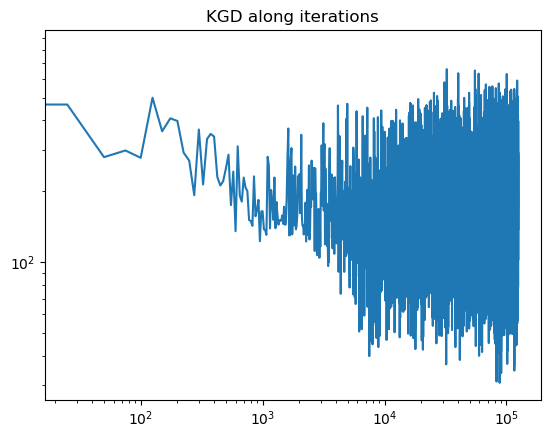

In [34]:
plt.plot(evaluations_grad_L,KGD_values)
plt.yscale('log')
plt.xscale('log')
plt.title('KGD along iterations')
plt.show()

# MFLD for long running time to have a contour of the true target.

In [ ]:
step_size = 1e-6
T = 50000

key = random.PRNGKey(2025)
n_particles = 2000
params_init = jnp.stack([true_params] * n_particles, 0)
key, subkey = random.split(key)
X0 = params_init + 1e-5 * random.normal(subkey, params_init.shape)

all_particles_contour = MFLD.run_particles(step_size,T,X0,key)
X_fin_contour = all_particles_contour[-1]

# Save results

In [35]:
filename = f"saved_data/expe3_results_gamma_{gamma}_{kernel_name}.pkl"

In [36]:
import jax.numpy as jnp
import pickle

# Chargement depuis le fichier
with open(filename, "rb") as g:
    expe3_results = pickle.load(g)

In [ ]:
expe3_results["MFLD contour"]["X_fin"] = X_fin_contour
expe3_results["MFLD"]["X_fin"] = X_fin
expe3_results["MFLD"]["KGD_values"] = KGD_values
expe3_results["MFLD"]["gradL_eval"] = evaluations_grad_L

In [38]:
import pickle

# Sauvegarde dans un fichier binaire
with open(filename, "wb") as gg:
    pickle.dump(expe3_results, gg)